# Step 3 - Pretraining the atmosphere field (warm start)

Fit the step-1 field `f_theta(x,y,z)` (atmosphere_field.py) to the step-2 starting atmosphere
(FAL-C clone + velocity structure) so the PINN begins the inversion warm. Supervised fit: random
minibatches of grid points, per-channel-balanced loss (P compared in log10), optax Adam. No RT yet.

In [1]:
import os, sys
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
sys.path.insert(0, os.path.abspath('..')); sys.path.insert(0, os.path.abspath('.'))
%matplotlib inline
import time, numpy as np, jax, matplotlib.pyplot as plt
import atmosphere_field as af, pretrain as pt
coords, tgt7, shape, z = pt.load_target()
print('grid', shape, ' N points', coords.shape[0], ' z', z[0], '..', z[-1], 'km')
params0 = af.init_params(jax.random.PRNGKey(0))   # anchored init (mid-photosphere)
print('initial loss (anchored):', float(pt.loss_fn(params0, coords, tgt7)))

grid (128, 128, 56)  N points 917504  z -100.0 .. 1000.0 km
initial loss (anchored): 0.7933741853196098


### Train

In [ ]:
t0 = time.time()
params, hist = pt.train(params0, coords, tgt7, steps=6000, batch=8192, lr=3e-3)
print(f'trained 6000 steps in {time.time()-t0:.0f}s   final loss {hist[-1,1]:.3e}')
plt.figure(figsize=(5,3.2))
plt.semilogy(hist[:,0], hist[:,1]); plt.xlabel('step'); plt.ylabel('loss (balanced MSE)')
plt.title('pretraining loss'); plt.grid(alpha=.3); plt.show()

### Accuracy vs the target, and save the warm-start weights

In [3]:
pred = pt.predict_grid(params, coords)
print('per-channel error over the full grid:')
for ch, s in pt.channel_errors(pred, tgt7).items():
    print(f'  {ch:6s} {s}')
out_w = '/dat/milic/adora_pinn_develop/pretrained_field.npz'
af.save_params(out_w, params); print('saved', out_w)

per-channel error over the full grid:
  T      RMS=3.962e+00
  P      RMS=3.945e+01, 4.06e-03 dex
  vz     RMS=1.426e+01
  Bx     RMS=1.007e-119
  By     RMS=9.067e-126
  Bz     RMS=9.389e-86
  vturb  RMS=4.120e+00
saved /dat/milic/adora_pinn_develop/pretrained_field.npz


### Field vs target: vertical profiles and the vz map
Column at pixel (0,0) for T, log10 P, vturb, vz; and the horizontal vz pattern (target vs field vs
residual) at the photosphere slice.

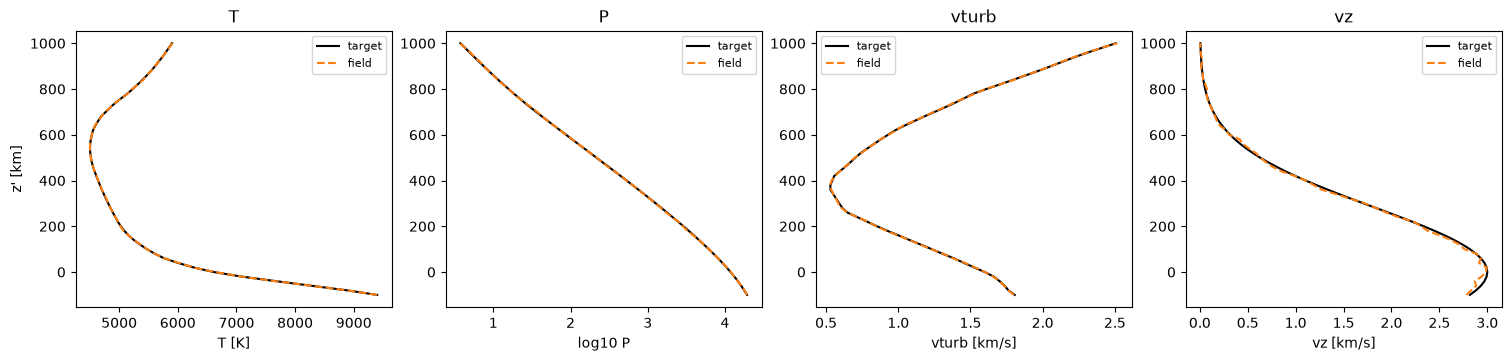

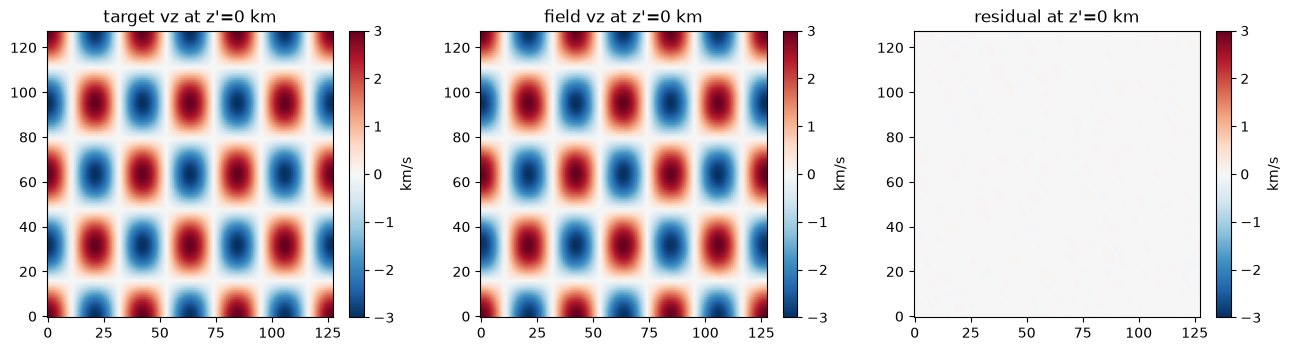

In [ ]:
nx, ny, nz = shape
d = np.load(pt.DEFAULT_ATM, allow_pickle=True)
Pf = {ch: pred[ch].reshape(nx, ny, nz) for ch in af.CHANNELS}
fig, ax = plt.subplots(1, 4, figsize=(15, 3.5), layout='constrained')
for a, (ch, lab, sc) in zip(ax, [('T','T [K]',1),('P','log10 P',None),('vturb','vturb [km/s]',1e3),('vz','vz [km/s]',1e3)]):
    tt = d[ch][0,0]; pp = Pf[ch][0,0]
    if ch=='P':
        a.plot(z, np.log10(tt), 'k-', label='target'); a.plot(z, np.log10(pp), 'C1--', label='field')
    else:
        a.plot(z, tt/sc, 'k-', label='target'); a.plot(z, pp/sc, 'C1--', label='field')
    a.set(xlabel=lab, ylabel="z' [km]" if ch=='T' else None, title=ch); a.legend(fontsize=8)
plt.show()
iz = int(np.argmin(np.abs(z-0.0)))
vt_t = d['vz'][:,:,iz]/1e3; vt_p = Pf['vz'][:,:,iz]/1e3; m = np.abs(vt_t).max()
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), layout='constrained')
for a, (arr, ti) in zip(ax, [(vt_t,'target vz'),(vt_p,'field vz'),(vt_p-vt_t,'residual')]):
    im = a.imshow(arr.T, origin='lower', cmap='RdBu_r', vmin=-m, vmax=m)
    plt.colorbar(im, ax=a, label='km/s'); a.set(title=f"{ti} at z'={z[iz]:.0f} km")
plt.show()

### Summary
The field reproduces the FAL-C stratification (T, P, vturb) and the horizontal vz pattern from the
warm-start anchor, giving weights the inversion can start from. Errors are the per-channel RMS above;
the residual vz map shows what the bandwidth-limited field cannot capture. Weights saved for step 4.